# Multimodal ECG + Echo Preprocessing — Local PC
Adapted from Colab notebook. Runs fully offline on your Windows machine.

## 0. Install Dependencies

In [1]:
# Run once — comment out after first install
# !pip install wfdb pydicom neurokit2 timm tqdm Pillow numpy pandas matplotlib

## 1. Paths — Edit These

In [2]:
import os

ECHO_DIR = r"C:\Users\anwme\Desktop\Datasets\Physionet\Physionet-ECHO"
ECG_DIR  = r"C:\Users\anwme\Desktop\Datasets\Physionet\Physionet-ECG"

# Path to your final_dataset_clean.csv (copy it locally if it was on Drive)
CSV_PATH = r"C:\Users\anwme\Desktop\Preprocessing\final_dataset.csv"

# Where preprocessed .npz files will be saved
CACHE_DIR = r"C:\Users\anwme\Desktop\Datasets\cache"

os.makedirs(CACHE_DIR, exist_ok=True)

print("=== ECHO directory ===")
echo_contents = os.listdir(ECHO_DIR)
print(f"Total items: {len(echo_contents)}")
print(f"First 10: {echo_contents[:10]}")

print("\n=== ECG directory ===")
ecg_contents = os.listdir(ECG_DIR)
print(f"Total items: {len(ecg_contents)}")
print(f"First 10: {ecg_contents[:10]}")

=== ECHO directory ===
Total items: 1714
First 10: ['p10024120', 'p10024736', 'p10036086', 'p10040025', 'p10046592', 'p10080695', 'p10087189', 'p10096391', 'p10102878', 'p10103763']

=== ECG directory ===
Total items: 1714
First 10: ['p10024120', 'p10024736', 'p10036086', 'p10040025', 'p10046592', 'p10080695', 'p10087189', 'p10096391', 'p10102878', 'p10103763']


## 2. Explore Data Structure

In [3]:
# Check if items are folders or files
sample = echo_contents[0]
sample_path = os.path.join(ECHO_DIR, sample)
print(f"Echo sample '{sample}' is {'DIR' if os.path.isdir(sample_path) else 'FILE'}")
if os.path.isdir(sample_path):
    print(f"Contents: {os.listdir(sample_path)[:5]}")

sample = ecg_contents[0]
sample_path = os.path.join(ECG_DIR, sample)
print(f"ECG sample '{sample}' is {'DIR' if os.path.isdir(sample_path) else 'FILE'}")
if os.path.isdir(sample_path):
    print(f"Contents: {os.listdir(sample_path)[:5]}")

Echo sample 'p10024120' is DIR
Contents: ['s96561814']
ECG sample 'p10024120' is DIR
Contents: ['s48734398']


## 3. Quick ECG Sanity Check

Loading: C:\Users\anwme\Desktop\Datasets\Physionet\Physionet-ECG\p10024120\s48734398\48734398
Shape: (5000, 12)  |  fs: 500 Hz  |  Leads: ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


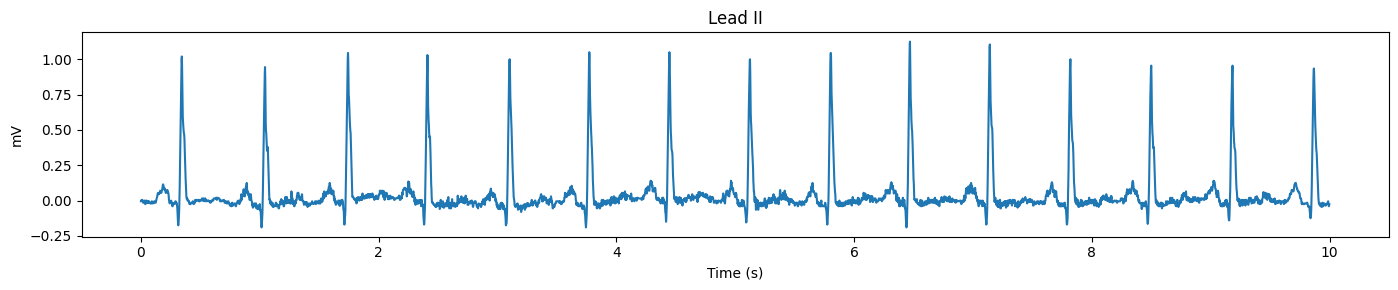

In [4]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

# Find first .hea file (walks subdirectories too)
hea_path = None
for root, dirs, files in os.walk(ECG_DIR):
    for f in files:
        if f.endswith('.hea'):
            hea_path = os.path.join(root, f[:-4])  # wfdb wants path without extension
            break
    if hea_path:
        break

print(f"Loading: {hea_path}")
record = wfdb.rdrecord(hea_path)
print(f"Shape: {record.p_signal.shape}  |  fs: {record.fs} Hz  |  Leads: {record.sig_name}")

lead_idx = record.sig_name.index('II') if 'II' in record.sig_name else 1
t = np.arange(record.p_signal.shape[0]) / record.fs
plt.figure(figsize=(14, 3))
plt.plot(t, record.p_signal[:, lead_idx])
plt.xlabel('Time (s)'); plt.ylabel('mV'); plt.title('Lead II')
plt.tight_layout()
plt.show()

## 4. Quick Echo (DICOM) Sanity Check

Loading: C:\Users\anwme\Desktop\Datasets\Physionet\Physionet-ECHO\p10024120\s96561814\96561814_0001.dcm
Pixel shape      : (64, 708, 1016, 3)
Photometric      : YBR_FULL_422
NumberOfFrames   : 64


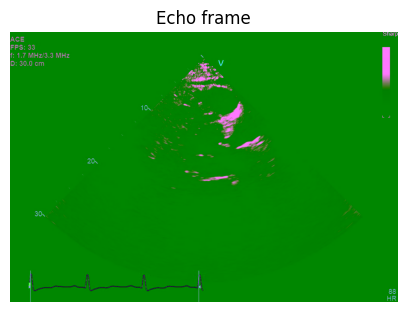

In [5]:
import pydicom
from pydicom.pixels import convert_color_space

# Find first .dcm file
dcm_path = None
for root, dirs, files in os.walk(ECHO_DIR):
    for f in files:
        if f.endswith('.dcm'):
            dcm_path = os.path.join(root, f)
            break
    if dcm_path:
        break

print(f"Loading: {dcm_path}")
dcm = pydicom.dcmread(dcm_path)
print(f"Pixel shape      : {dcm.pixel_array.shape}")
print(f"Photometric      : {dcm.PhotometricInterpretation}")
print(f"NumberOfFrames   : {getattr(dcm, 'NumberOfFrames', 1)}")

px = dcm.pixel_array
if dcm.PhotometricInterpretation == 'YBR_FULL_422':
    px = convert_color_space(px, 'YBR_FULL_422', 'RGB', per_frame=(px.ndim == 4))

# Display first/only frame
frame = px[0] if px.ndim == 4 else px
plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.axis('off')
plt.title('Echo frame')
plt.show()

## 5. Load CSV and Resolve Local Paths

In [6]:
import pandas as pd
import os

df = pd.read_csv(CSV_PATH)
print(f"Rows in CSV: {len(df)}")

# Preview raw CSV paths to understand their format
print("\nRaw CSV path samples:")
print("  ecg_path  :", df['ecg_path'].iloc[0])
print("  echo_ED   :", df['echo_path_ED'].iloc[0])

# Keep last 3 parts of path: p{id}/s{id}/filename
# e.g. ".../.../p10024120/s48734398/48734398" → "p10024120/s48734398/48734398"
def last_3_parts(p):
    parts = p.replace("\\", "/").split("/")
    return os.path.join(*parts[-3:])   # p.../s.../file

df['ecg_rel']      = df['ecg_path'].apply(last_3_parts)
df['echo_ED_rel']  = df['echo_path_ED'].apply(last_3_parts)
df['echo_Mid_rel'] = df['echo_path_Mid'].apply(last_3_parts)
df['echo_ES_rel']  = df['echo_path_ES'].apply(last_3_parts)

df['ecg_full']  = df['ecg_rel'].apply(lambda x: os.path.join(ECG_DIR, x))
df['echo_ED']   = df['echo_ED_rel'].apply(lambda x: os.path.join(ECHO_DIR, x))
df['echo_Mid']  = df['echo_Mid_rel'].apply(lambda x: os.path.join(ECHO_DIR, x))
df['echo_ES']   = df['echo_ES_rel'].apply(lambda x: os.path.join(ECHO_DIR, x))

# Verify a few resolved paths look correct
print("\nResolved path samples:")
print("  ecg_full :", df['ecg_full'].iloc[0])
print("  echo_ED  :", df['echo_ED'].iloc[0])

# Check file availability
def row_available(r):
    return (os.path.exists(r['ecg_full'] + '.hea') and
            os.path.exists(r['ecg_full'] + '.dat') and
            os.path.exists(r['echo_ED'])  and
            os.path.exists(r['echo_Mid']) and
            os.path.exists(r['echo_ES']))

print("\nScanning local files...")
df['available'] = df.apply(row_available, axis=1)
df_avail = df[df['available']].copy()

print(f"\nAvailable: {len(df_avail)} / {len(df)}")
print(f"\nSplit counts:\n{df_avail['split'].value_counts()}")
print(f"\nstructural_coarse distribution:\n{df_avail['structural_coarse'].value_counts()}")

df_avail.to_csv(os.path.join(CACHE_DIR, 'df_avail.csv'), index=False)
print(f"\nSaved df_avail.csv")

Rows in CSV: 5448

Raw CSV path samples:
  ecg_path  : files/p1997/p19971226/s40000903/40000903
  echo_ED   : files/p19/p19971226/s90266158/90266158_0001.dcm

Resolved path samples:
  ecg_full : C:\Users\anwme\Desktop\Datasets\Physionet\Physionet-ECG\p19971226\s40000903\40000903
  echo_ED  : C:\Users\anwme\Desktop\Datasets\Physionet\Physionet-ECHO\p19971226\s90266158\90266158_0001.dcm

Scanning local files...

Available: 5448 / 5448

Split counts:
split
train    3761
test     1124
val       563
Name: count, dtype: int64

structural_coarse distribution:
structural_coarse
ischemic_heart_disease    2268
heart_failure             1339
normal                     948
cardiomyopathy             543
valve_disease              213
pericardial_disease        100
congenital                  37
Name: count, dtype: int64

Saved df_avail.csv


## 6. Loader Functions

df_avail has 5448 rows
Row 0: ECG (12, 5000) @ 500Hz | ED (708, 1016, 3) | Mid (708, 1016, 3) | ES (708, 1016, 3) | label=ischemic_heart_disease
Row 1: ECG (12, 5000) @ 500Hz | ED (708, 1016, 3) | Mid (708, 1016, 3) | ES (708, 1016, 3) | label=heart_failure
Row 2: ECG (12, 5000) @ 500Hz | ED (708, 1016, 3) | Mid (708, 1016, 3) | ES (708, 1016, 3) | label=ischemic_heart_disease
Row 3: ECG (12, 5000) @ 500Hz | ED (708, 1016, 3) | Mid (708, 1016, 3) | ES (708, 1016, 3) | label=ischemic_heart_disease
Row 4: ECG (12, 5000) @ 500Hz | ED (708, 1016, 3) | Mid (708, 1016, 3) | ES (708, 1016, 3) | label=normal


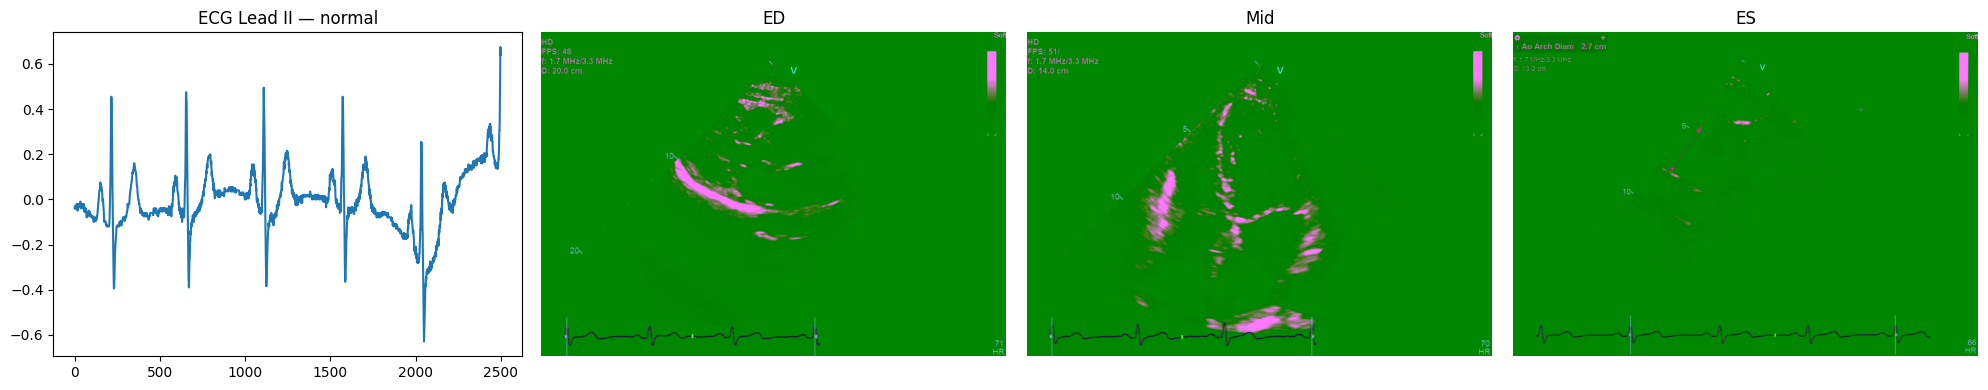

In [7]:
import wfdb
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from pydicom.pixels import convert_color_space

def load_ecg(ecg_path_no_ext):
    rec = wfdb.rdrecord(ecg_path_no_ext)
    sig = rec.p_signal.astype(np.float32).T   # (12, 5000)
    return sig, rec.fs

def load_echo_frame(dcm_path):
    dcm = pydicom.dcmread(dcm_path)
    px = dcm.pixel_array
    if dcm.PhotometricInterpretation == 'YBR_FULL_422':
        px = convert_color_space(px, 'YBR_FULL_422', 'RGB')
    if px.ndim == 4:
        px = px[px.shape[0] // 2]
    return px

# ── Debug: check df_avail before looping ──────────────────────────────────────
print(f"df_avail has {len(df_avail)} rows")
if len(df_avail) == 0:
    print("\n⚠️  df_avail is empty — checking why...")
    print(f"Total rows in df: {len(df)}")
    # Sample the first row and check each file manually
    row = df.iloc[0]
    print(f"\nSample ecg_full  : {row['ecg_full']}")
    print(f"  .hea exists    : {os.path.exists(row['ecg_full'] + '.hea')}")
    print(f"  .dat exists    : {os.path.exists(row['ecg_full'] + '.dat')}")
    print(f"echo_ED exists   : {os.path.exists(row['echo_ED'])}")
    print(f"echo_Mid exists  : {os.path.exists(row['echo_Mid'])}")
    print(f"echo_ES exists   : {os.path.exists(row['echo_ES'])}")
    raise RuntimeError("Fix the paths above before continuing.")

# ── Quick test on first 5 rows ────────────────────────────────────────────────
results = []
for i, row in df_avail.head(5).iterrows():
    ecg, fs = load_ecg(row['ecg_full'])
    ed  = load_echo_frame(row['echo_ED'])
    mid = load_echo_frame(row['echo_Mid'])
    es  = load_echo_frame(row['echo_ES'])
    results.append((ecg, ed, mid, es, row))
    print(f"Row {i}: ECG {ecg.shape} @ {fs}Hz | ED {ed.shape} | Mid {mid.shape} | ES {es.shape} | label={row['structural_coarse']}")

# Visualize last loaded sample
ecg, ed, mid, es, row = results[-1]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].plot(ecg[1, :2500])
axes[0].set_title(f'ECG Lead II — {row["structural_coarse"]}')
for ax, img, name in zip(axes[1:], [ed, mid, es], ['ED', 'Mid', 'ES']):
    ax.imshow(img); ax.set_title(name); ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Full Preprocessing Pipeline → .npz Files


Saves `train.npz`, `val.npz`, `test.npz` + `classes.json` to `CACHE_DIR`.  
Checkpoints progress every ~10 % so you can resume if interrupted.

In [10]:
import os, numpy as np, pandas as pd, wfdb, pydicom
import json, gc, shutil, warnings, logging
from pydicom.pixels import convert_color_space
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=UserWarning, module='pydicom')
logging.getLogger('pydicom').setLevel(logging.ERROR)

# ── Config ────────────────────────────────────────────────────────────────────
ECHO_SIZE = 224
ECG_LEN   = 5000
MAX_DCM_BYTES    = 15 * 1024 * 1024   # 15 MB on disk
MAX_PIXEL_BYTES  = 200 * 1024 * 1024  # 200 MB decompressed

df = pd.read_csv(os.path.join(CACHE_DIR, 'df_avail.csv'))
df = df[df['structural_coarse'] != 'congenital'].reset_index(drop=True)
CLASSES      = sorted(df['structural_coarse'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
print(f"Structural classes ({len(CLASSES)}): {CLASSES}")

# Arrhythmia binary mapping (NEW)
def get_arrhythmia_binary(row):
    return 0 if row['arrhythmia_coarse'] == 'normal' else 1

def get_structural_binary(row):
    return 0 if row['structural_coarse'] == 'normal' else 1

print(f"Total rows: {len(df)}")

# ── Preprocessing helpers ─────────────────────────────────────────────────────
def preprocess_ecg(path_no_ext):
    sig = wfdb.rdrecord(path_no_ext).p_signal.astype(np.float32).T  # (12, T)
    mean = sig.mean(axis=1, keepdims=True)
    std  = sig.std(axis=1, keepdims=True) + 1e-6
    return np.clip((sig - mean) / std, -8, 8).astype(np.float32)

def preprocess_echo(dcm_path):
    fsize = os.path.getsize(dcm_path)
    if fsize > MAX_DCM_BYTES:
        raise ValueError(f"DICOM too large on disk: {fsize/1e6:.1f} MB")

    # Read metadata only first (fast memory check)
    dcm = pydicom.dcmread(dcm_path, stop_before_pixels=True)
    rows    = int(getattr(dcm, 'Rows', 0))
    cols    = int(getattr(dcm, 'Columns', 0))
    frames  = int(getattr(dcm, 'NumberOfFrames', 1))
    samples = int(getattr(dcm, 'SamplesPerPixel', 1))
    bits    = int(getattr(dcm, 'BitsAllocated', 8))
    photo   = dcm.PhotometricInterpretation
    estimated_bytes = rows * cols * frames * samples * (bits // 8)
    del dcm

    if estimated_bytes > MAX_PIXEL_BYTES:
        raise ValueError(f"Pixel array would be {estimated_bytes/1e6:.0f} MB")

    # Decode pixels
    dcm = pydicom.dcmread(dcm_path)
    px  = dcm.pixel_array
    del dcm

    if photo == 'YBR_FULL_422':
        px = convert_color_space(px, 'YBR_FULL_422', 'RGB')
    if px.ndim == 4:
        px = px[px.shape[0] // 2].copy()

    # Crop border (remove echo machine UI overlays)
    H, W = px.shape[:2]
    px = px[int(H*0.06):int(H*0.88), int(W*0.14):int(W*0.86)]

    # Convert to grayscale
    if px.ndim == 3:
        gray = (0.299*px[..., 0] + 0.587*px[..., 1] + 0.114*px[..., 2]).astype(np.uint8)
    else:
        gray = px.astype(np.uint8)
    del px

    gray = np.array(
        Image.fromarray(gray).resize((ECHO_SIZE, ECHO_SIZE), Image.BILINEAR),
        dtype=np.uint8
    )
    return gray  # (224, 224) uint8

def process_one(i, row):
    try:
        ecg  = preprocess_ecg(row['ecg_full'])
        ed   = preprocess_echo(row['echo_ED'])
        mid  = preprocess_echo(row['echo_Mid'])
        es   = preprocess_echo(row['echo_ES'])
        echo = np.stack([ed, mid, es])         # (3, 224, 224)
        return ecg, echo, CLASS_TO_IDX[row['structural_coarse']], None
    except Exception as e:
        return None, None, None, str(e)

# ── Main loop ─────────────────────────────────────────────────────────────────
for split_name in ['train', 'val', 'test']:
    final_path = os.path.join(CACHE_DIR, f'{split_name}.npz')
    if os.path.exists(final_path):
        print(f"\n{split_name}.npz already exists — skipping")
        continue

    subset    = df[df['split'] == split_name].reset_index(drop=True)
    N         = len(subset)
    split_dir = os.path.join(CACHE_DIR, f'{split_name}_samples')
    os.makedirs(split_dir, exist_ok=True)

    log_path = os.path.join(CACHE_DIR, f'{split_name}_done.json')
    done = {}
    if os.path.exists(log_path):
        with open(log_path) as f:
            done = json.load(f)
        # Keep only entries that still have their file on disk
        done = {
            k: v for k, v in done.items()
            if v == 'failed' or os.path.exists(os.path.join(split_dir, f'{k}.npz'))
        }

    print(f"\n=== {split_name}: {N} samples, {len(done)} already done ===")
    todo = [i for i in range(N) if str(i) not in done]
    ckpt_every = max(1, N // 10)

    def save_log():
        with open(log_path, 'w') as f:
            json.dump(done, f)

    pbar = tqdm(todo, initial=len(done), total=N, desc=split_name)
    since_ckpt = 0
    for i in pbar:
        row = subset.iloc[i]
        ecg, echo, lbl, err = process_one(i, row)
        if ecg is not None:
            np.savez(os.path.join(split_dir, f'{i}.npz'),ecg=ecg, echo=echo,label=lbl,label_struct_bin=get_structural_binary(row),label_arr_bin=get_arrhythmia_binary(row))
            done[str(i)] = 'ok'
            del ecg, echo
        else:
            done[str(i)] = 'failed'
        since_ckpt += 1
        if since_ckpt >= ckpt_every:
            save_log()
            since_ckpt = 0
            ok     = sum(1 for v in done.values() if v == 'ok')
            failed = sum(1 for v in done.values() if v == 'failed')
            pbar.set_postfix(ok=ok, failed=failed, ckpt='✓')
            gc.collect()
    save_log()
    gc.collect()

    # Assemble individual .npz files → single split .npz
    ok_indices = sorted([int(k) for k, v in done.items() if v == 'ok'])
    if not ok_indices:
        print(f"  No valid samples for {split_name}")
        continue

    M = len(ok_indices)
    print(f"  Assembling {split_name}.npz ({M} samples)...")
    ecgs         = np.zeros((M, 12, ECG_LEN),             dtype=np.float32)
    echoes       = np.zeros((M, 3, ECHO_SIZE, ECHO_SIZE), dtype=np.uint8)
    labels       = np.zeros(M,                            dtype=np.int64)
    labels_s_bin = np.zeros(M,                            dtype=np.int64)
    labels_a_bin = np.zeros(M,                            dtype=np.int64)

    for j, i in enumerate(tqdm(ok_indices, desc='Assembling', leave=False)):
        d = np.load(os.path.join(split_dir, f'{i}.npz'))
        ecgs[j]         = d['ecg']
        echoes[j]       = d['echo']
        labels[j]       = int(d['label'])
        labels_s_bin[j] = int(d['label_struct_bin'])
        labels_a_bin[j] = int(d['label_arr_bin'])

    np.savez(final_path, ecg=ecgs, echo=echoes,
         label=labels,
         label_struct_bin=labels_s_bin,
         label_arr_bin=labels_a_bin)
    print(f"  ✓ {split_name}: {M} samples saved to {final_path}")
    try:
        shutil.rmtree(split_dir)
    except PermissionError:
        print(f"  ⚠ Could not delete temp folder {split_dir} — delete manually later")
    del ecgs, echoes, labels
    gc.collect()

# Save class map
classes_path = os.path.join(CACHE_DIR, 'classes.json')
with open(classes_path, 'w') as f:
    json.dump({'classes': CLASSES, 'class_to_idx': CLASS_TO_IDX}, f, indent=2)

print(f"\n✓ All done. Output files:")
for fname in ['train.npz', 'val.npz', 'test.npz', 'classes.json']:
    p = os.path.join(CACHE_DIR, fname)
    if os.path.exists(p):
        size_mb = os.path.getsize(p) / 1e6
        print(f"  {fname:20s} {size_mb:8.1f} MB")

Structural classes (6): ['cardiomyopathy', 'heart_failure', 'ischemic_heart_disease', 'normal', 'pericardial_disease', 'valve_disease']
Total rows: 5411

train.npz already exists — skipping

=== val: 558 samples, 0 already done ===


val:   0%|          | 0/558 [00:00<?, ?it/s]

  Assembling val.npz (465 samples)...


Assembling:   0%|          | 0/465 [00:00<?, ?it/s]

  ✓ val: 465 samples saved to C:\Users\anwme\Desktop\Datasets\cache\val.npz
  ⚠ Could not delete temp folder C:\Users\anwme\Desktop\Datasets\cache\val_samples — delete manually later

=== test: 1117 samples, 0 already done ===


test:   0%|          | 0/1117 [00:00<?, ?it/s]

  Assembling test.npz (952 samples)...


Assembling:   0%|          | 0/952 [00:00<?, ?it/s]

  ✓ test: 952 samples saved to C:\Users\anwme\Desktop\Datasets\cache\test.npz
  ⚠ Could not delete temp folder C:\Users\anwme\Desktop\Datasets\cache\test_samples — delete manually later

✓ All done. Output files:
  train.npz              1247.0 MB
  val.npz                 181.6 MB
  test.npz                371.8 MB
  classes.json              0.0 MB


## 8. Verify Output

ECG   : (3193, 12, 5000)  dtype=float32
Echo  : (3193, 3, 224, 224)  dtype=uint8
Labels: (3193,)

Class distribution in train:
  cardiomyopathy                 314
  heart_failure                  814
  ischemic_heart_disease         1329
  normal                         595
  pericardial_disease            28
  valve_disease                  113


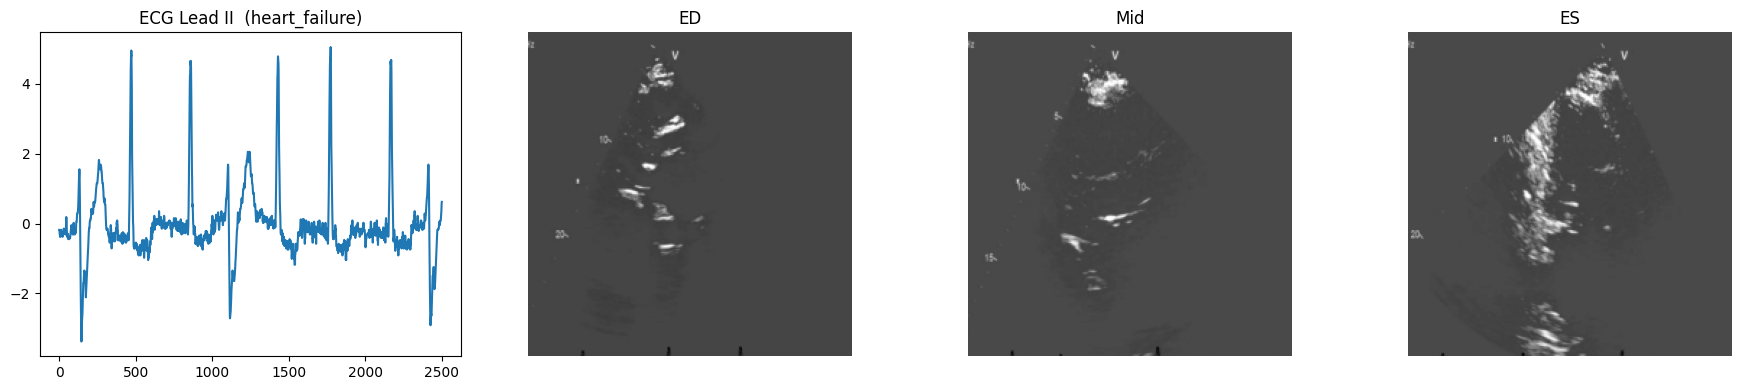

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os

with open(os.path.join(CACHE_DIR, 'classes.json')) as f:
    meta = json.load(f)
CLASSES = meta['classes']

data = np.load(os.path.join(CACHE_DIR, 'train.npz'))
ecg, echo, label = data['ecg'], data['echo'], data['label']

print(f"ECG   : {ecg.shape}  dtype={ecg.dtype}")
print(f"Echo  : {echo.shape}  dtype={echo.dtype}")
print(f"Labels: {label.shape}")
print(f"\nClass distribution in train:")
for c, n in zip(*np.unique(label, return_counts=True)):
    print(f"  {CLASSES[c]:30s} {n}")

# Visualise one sample
idx = 0
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].plot(ecg[idx, 1, :2500])
axes[0].set_title(f'ECG Lead II  ({CLASSES[label[idx]]})')
for ax, phase, name in zip(axes[1:], echo[idx], ['ED', 'Mid', 'ES']):
    ax.imshow(phase, cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
import numpy as np

for split in ['train', 'val', 'test']:
    d = np.load(os.path.join(CACHE_DIR, f'{split}.npz'))
    print(f"\n{split}:")
    print(f"  Keys: {list(d.keys())}")
    print(f"  ECG:  {d['ecg'].shape}")
    print(f"  Echo: {d['echo'].shape}")
    ns = np.bincount(d['label_struct_bin'], minlength=2)
    na = np.bincount(d['label_arr_bin'], minlength=2)
    print(f"  Structural: normal={ns[0]}  disease={ns[1]}")
    print(f"  Arrhythmia: normal={na[0]}  arrhythmia={na[1]}")


train:
  Keys: ['ecg', 'echo', 'label', 'label_struct_bin', 'label_arr_bin']
  ECG:  (3193, 12, 5000)
  Echo: (3193, 3, 224, 224)
  Structural: normal=595  disease=2598
  Arrhythmia: normal=926  arrhythmia=2267

val:
  Keys: ['ecg', 'echo', 'label', 'label_struct_bin', 'label_arr_bin']
  ECG:  (465, 12, 5000)
  Echo: (465, 3, 224, 224)
  Structural: normal=59  disease=406
  Arrhythmia: normal=109  arrhythmia=356

test:
  Keys: ['ecg', 'echo', 'label', 'label_struct_bin', 'label_arr_bin']
  ECG:  (952, 12, 5000)
  Echo: (952, 3, 224, 224)
  Structural: normal=108  disease=844
  Arrhythmia: normal=241  arrhythmia=711
